# Lab1 - Data Exploration and Visualization

## Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from pandas.plotting import scatter_matrix
%matplotlib inline
plt.style.use('ggplot')
from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns
from scipy.stats import chi2_contingency
pd.set_option('display.max_columns', None)

# style
sns.set(style="whitegrid")

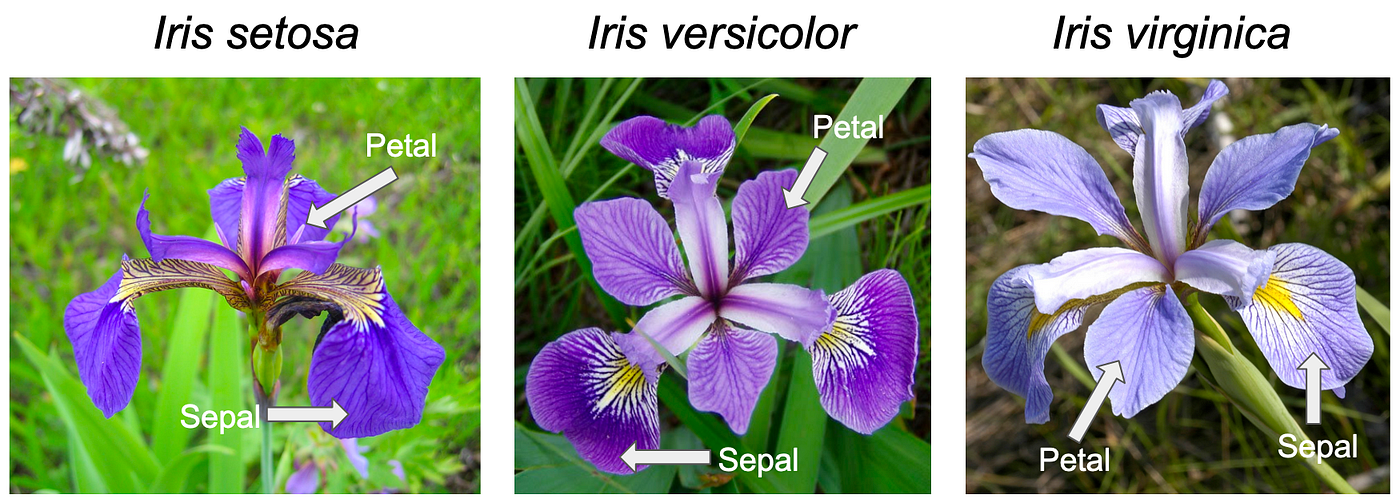

## Download and Read Data
Loading the iris dataset, where X = iris.data and y = iris.target.

In [2]:
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## Looking into the data

In [3]:

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa',1: 'versicolor',2: 'virginica'})

# view first rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [5]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
11,4.8,3.4,1.6,0.2,setosa
29,4.7,3.2,1.6,0.2,setosa
52,6.9,3.1,4.9,1.5,versicolor
49,5.0,3.3,1.4,0.2,setosa
126,6.2,2.8,4.8,1.8,virginica


## Exploratory Data Analysis - EDA

### Dataset Dimensions

In [6]:
df.shape

(150, 5)

### Listing Dataset Column Names

In [7]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

### Data Types

In [8]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

### Summary Statistics for Numerical Values

In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Checking for Missing Values

In [10]:
print("Missing values:\n", df.isnull().sum())
df.isnull().sum().sum()

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


0

### Identifying Duplicate Rows

In [11]:

print("Duplicate rows:", df.duplicated().sum())

# remove duplicates if any
#df = df.drop_duplicates()

Duplicate rows: 1


### Mean Values by Species

In [12]:
df.groupby('species').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


## Visual Exploration

### Histograms

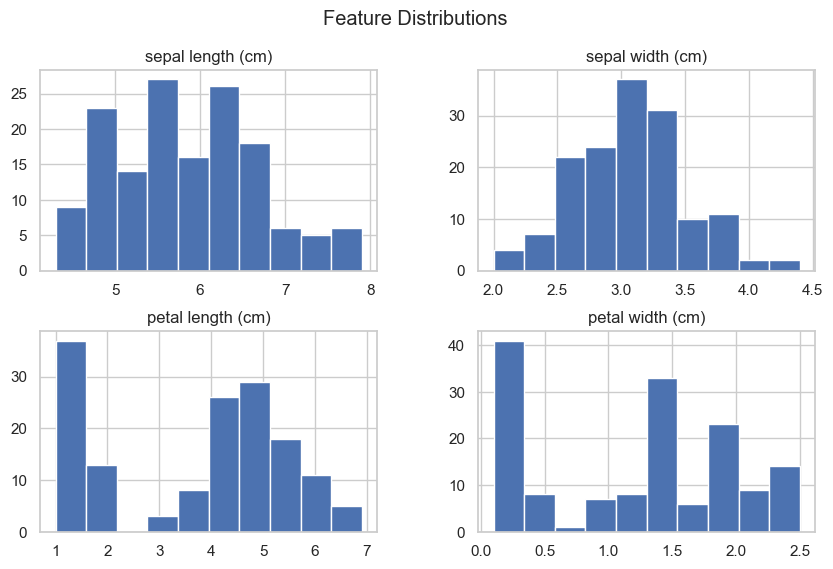

In [13]:
df.hist(figsize=(10,6))
plt.suptitle("Feature Distributions")
plt.show()

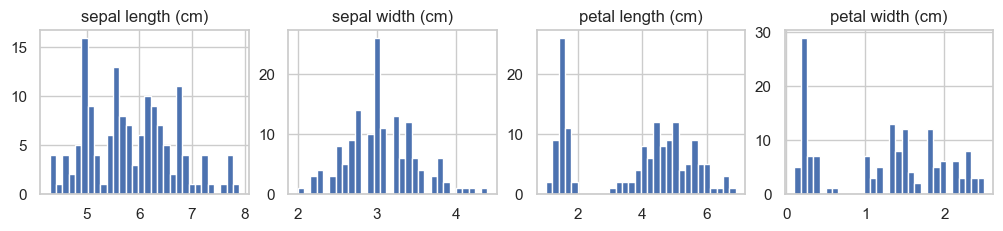

In [14]:
df.hist(bins=30,layout=(4, 4),figsize=(10, 8),sharex=False,sharey=False)
plt.tight_layout(pad=0.5, h_pad=0.5, w_pad=0.5)
#plt.tight_layout()
plt.show()

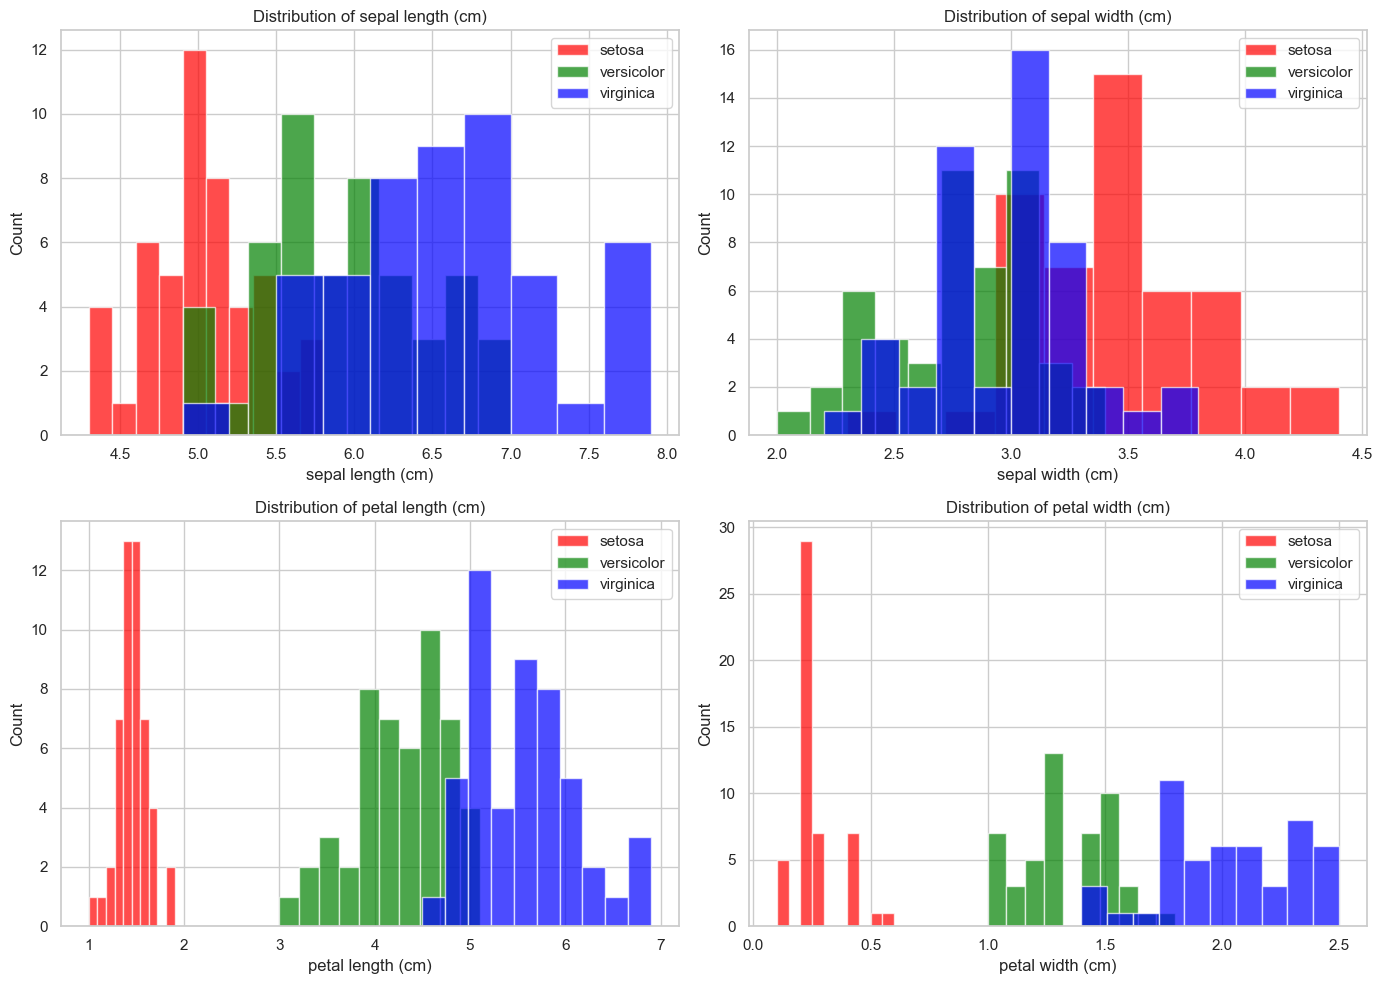

In [15]:
X = iris.data       # numeric features
y = iris.target     # species labels

# Plot histograms
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,10))
colors = ['red', 'green', 'blue']

for i, ax in enumerate(axes.flat):
    for label, color in zip(range(len(iris.target_names)), colors):
        ax.hist(X[y==label, i], label=iris.target_names[label], color=color, alpha=0.7)
    ax.set_xlabel(iris.feature_names[i])
    ax.set_ylabel("Count")
    ax.legend(loc='upper right')
    ax.set_title(f"Distribution of {iris.feature_names[i]}")

plt.tight_layout()
plt.show()

##### Comments
##### - Both petal characteristics can very much distinguish the 'Setosa' type.

### BoxPlots

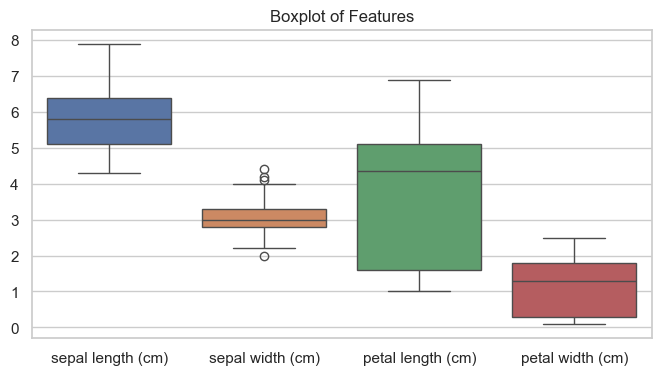

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df.drop('species', axis=1))
plt.title("Boxplot of Features")
plt.show()

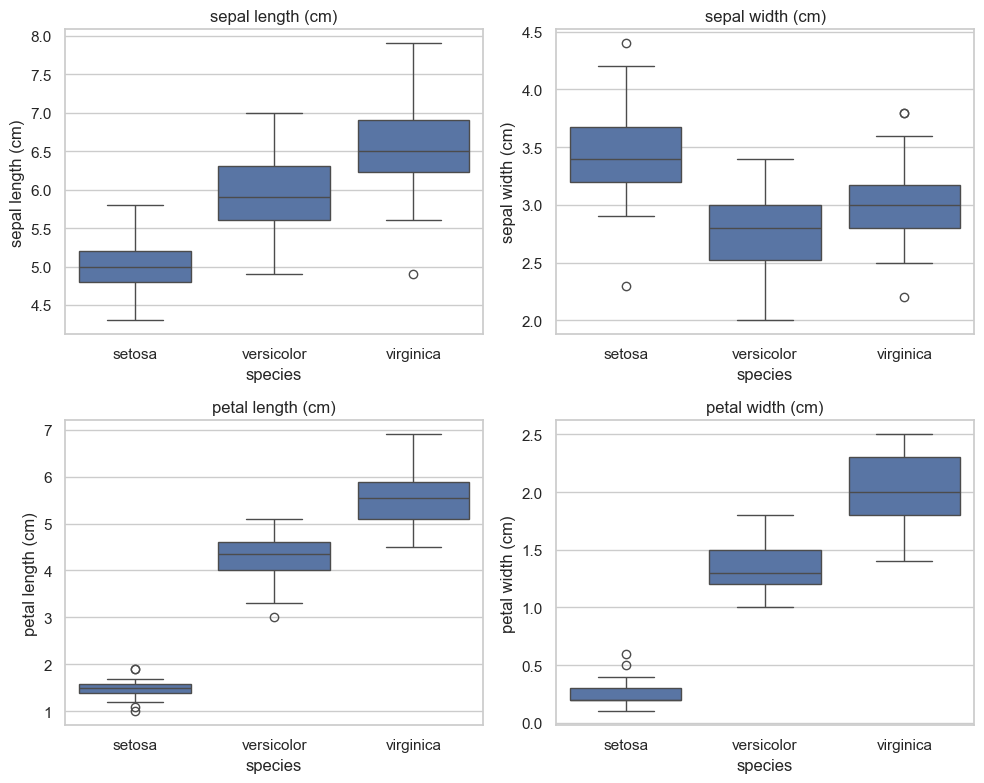

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, column in zip(axes.flatten(), df.columns[:-1]):
    sns.boxplot(x='species', y=column, data=df, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

### Scatter Plots

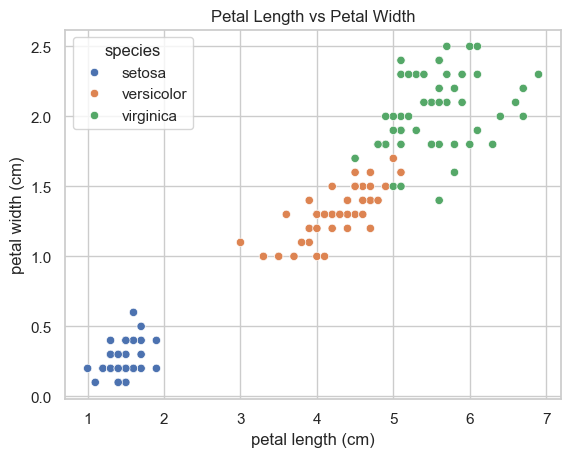

In [18]:
plt.figure()
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species', data=df)
plt.title("Petal Length vs Petal Width")
plt.show()

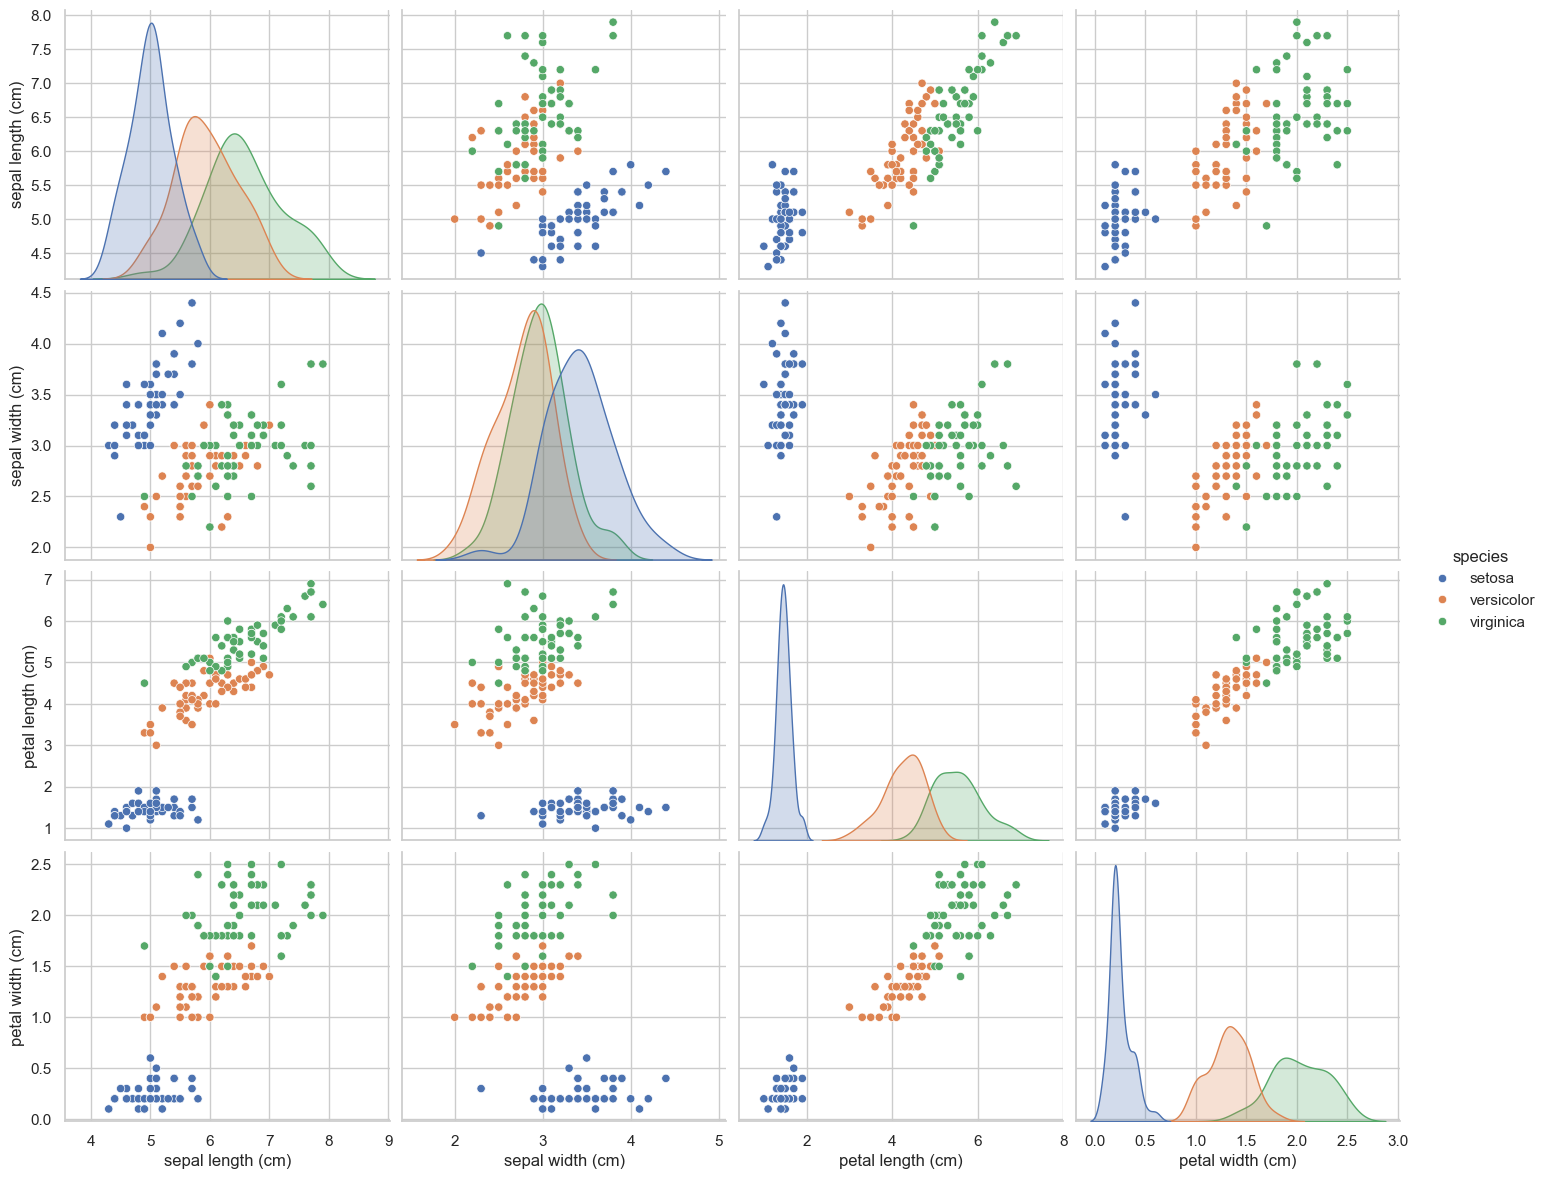

In [19]:
sns.pairplot(df, hue='species', height=3, aspect=1.2)
plt.show()

##### Comments:

##### -Both sepal features have a Gaussian distribution.
##### -The petal length has a high positive correlation with both sepal length and petal width.
##### -Again, 'Setosa' class is shown to be linearly separable from the other ones.

## 3-D Scatter Plot

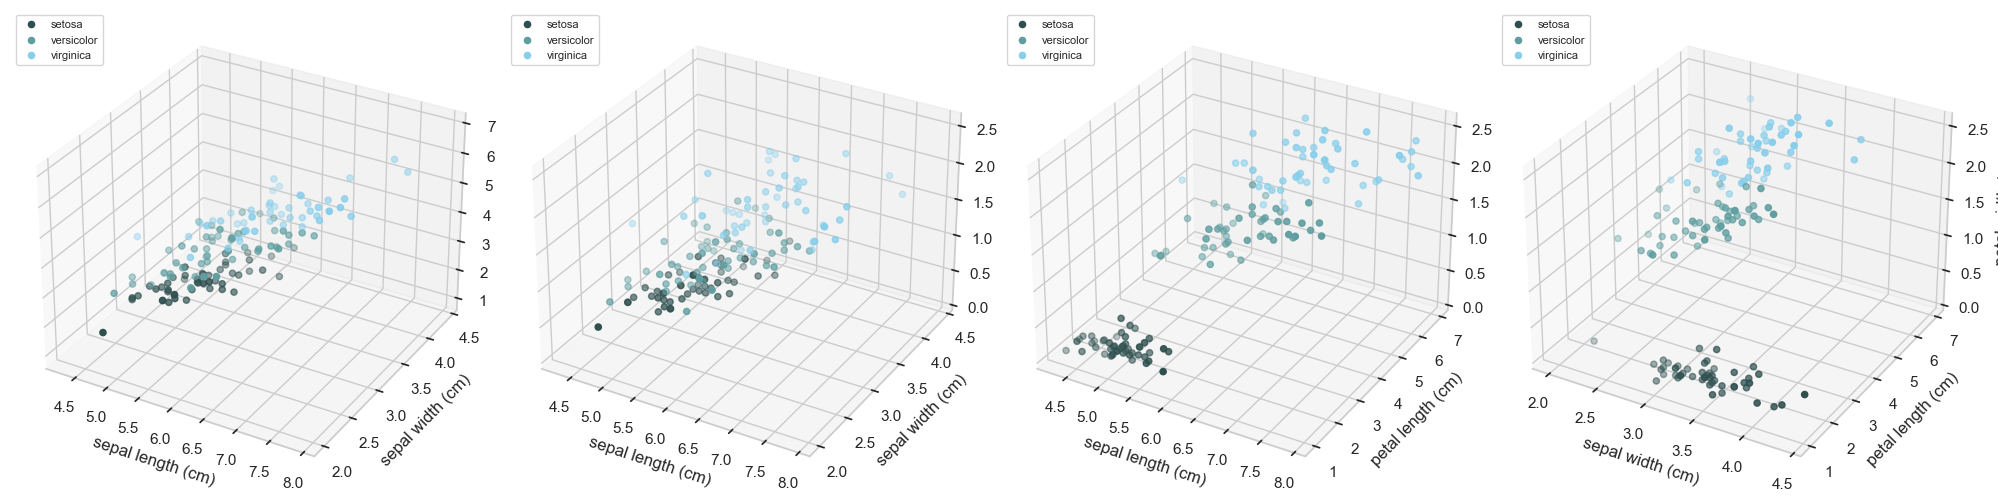

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessary for 3D plotting
from sklearn.datasets import load_iris
import numpy as np

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
features = iris.feature_names
classes = iris.target_names

# Plot settings
colors = ['darkslategray', 'cadetblue', 'skyblue']
plt.rcParams["figure.figsize"] = [20, 6]

fig = plt.figure()
n = len(features)
plot = 1

# Loop over all combinations of 3 features
from itertools import combinations

comb = list(combinations(range(n), 3))  # all 3-feature combinations

for idx, (i, j, k) in enumerate(comb):
    ax = fig.add_subplot(1, len(comb), plot, projection='3d')
    
    for label, color in zip(range(len(classes)), colors):
        X_cur = X[y==label]
        ax.scatter(X_cur[:, i], X_cur[:, j], X_cur[:, k], label=classes[label], color=color)
    
    ax.set_xlabel(features[i])
    ax.set_ylabel(features[j])
    ax.set_zlabel(features[k])
    ax.legend(loc='upper left', fontsize=8)
    
    plot += 1

plt.tight_layout()
plt.show()

###  Class Distribution

Count of each species species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


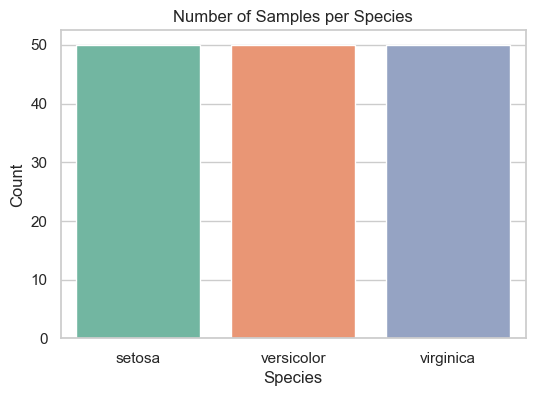

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
# Count of each species
print("Count of each species",df['species'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='species', hue='species', palette='Set2', legend=False)
plt.title('Number of Samples per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

### Cosine Similarity

Cosine Similarity

The cosine similarity between two vectors $\mathbf{A}$ and $\mathbf{B}$ is defined as:

$$
\text{cosine\_similarity}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \, \|\mathbf{B}\|}
$$

Where:  
- $\mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^n A_i B_i$ (dot product)  
- $\|\mathbf{A}\| = \sqrt{\sum_{i=1}^n A_i^2}$ (magnitude of A)  
- $\|\mathbf{B}\| = \sqrt{\sum_{i=1}^n B_i^2}$ (magnitude of B)

**Example:**  

Let $\mathbf{A} = [1, 2, 3], \mathbf{B} = [4, 5, 6]$

1. Dot product:  
$$
\mathbf{A} \cdot \mathbf{B} = 1*4 + 2*5 + 3*6 = 32
$$

2. Magnitudes:  
$$
\|\mathbf{A}\| = \sqrt{1^2 + 2^2 + 3^2} = \sqrt{14} \approx 3.7417
$$  
$$
\|\mathbf{B}\| = \sqrt{4^2 + 5^2 + 6^2} = \sqrt{77} \approx 8.775
$$

3. Cosine similarity:  
$$
\cos(\theta) = \frac{32}{3.7417 \times 8.775} \approx 0.9746
$$

**Interpretation:**  
- Values close to 1 → high similarity  
- 0 → no similarity  
- -1 → opposite directions



In [22]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute cosine similarity
cos_sim = cosine_similarity(numeric_df)
display(pd.DataFrame(cos_sim))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149
0,1.000000,0.998579,0.999987,0.999101,0.999758,0.999003,0.999080,0.999780,0.999135,0.998765,0.999995,0.998972,0.998830,0.999764,0.998541,0.998102,0.998906,0.999876,0.999641,0.999139,0.998551,0.999159,0.996713,0.997264,0.995868,0.997228,0.998819,0.999886,0.999761,0.998655,0.998359,0.998793,0.997776,0.998503,0.998873,0.999238,0.999091,0.999381,0.999842,0.999763,0.999742,0.991413,0.999566,0.997390,0.996597,0.998737,0.999000,0.999729,0.999954,0.999820,0.928380,0.925986,0.917664,0.906401,0.913458,0.907332,0.919065,0.932998,0.920305,0.916009,0.911670,0.923551,0.913877,0.908586,0.940232,0.931410,0.907636,0.924739,0.892315,0.921750,0.902616,0.930590,0.891041,0.908355,0.927322,0.927791,0.912364,0.906414,0.912300,0.941175,0.920729,0.925864,0.929022,0.883292,0.903309,0.922843,0.921207,0.903813,0.925644,0.913323,0.902713,0.914786,0.922580,0.931111,0.913807,0.925242,0.921149,0.924958,0.947516,0.921976,0.860081,0.873442,0.879002,0.874842,0.868656,0.866937,0.870881,0.871454,0.863447,0.883984,0.900368,0.879361,0.885953,0.865907,0.865480,0.886314,0.885306,0.884942,0.845206,0.870936,0.883658,0.877004,0.861079,0.892675,0.885988,0.887453,0.897338,0.897893,0.868886,0.890494,0.874987,0.898912,0.867028,0.893759,0.866400,0.879971,0.877662,0.886129,0.899386,0.893508,0.878256,0.898527,0.873442,0.875613,0.878619,0.889556,0.880900,0.891786,0.883909,0.886703
1,0.998579,1.000000,0.998791,0.998794,0.997241,0.996926,0.996280,0.998914,0.999261,0.999652,0.998651,0.997551,0.999815,0.997669,0.996100,0.993693,0.995864,0.998492,0.999251,0.995995,0.999692,0.996712,0.991309,0.998114,0.995241,0.999548,0.998285,0.999113,0.999429,0.998285,0.999152,0.999524,0.993069,0.994187,0.999799,0.999029,0.998961,0.996405,0.998863,0.999294,0.997690,0.996867,0.997013,0.996231,0.994499,0.999799,0.996074,0.998376,0.998227,0.999408,0.940003,0.936294,0.929869,0.919868,0.926330,0.918588,0.928867,0.943428,0.932776,0.926006,0.925637,0.933629,0.928894,0.920269,0.949389,0.942714,0.917464,0.936304,0.908122,0.933956,0.912299,0.942025,0.905593,0.920615,0.939099,0.939478,0.925929,0.918926,0.923562,0.952366,0.933271,0.938268,0.940343,0.896369,0.912687,0.931194,0.932858,0.919088,0.934909,0.925459,0.914687,0.925771,0.934672,0.942539,0.925108,0.934864,0.931401,0.936359,0.957209,0.932723,0.871272,0.886141,0.892916,0.887782,0.881556,0.882018,0.882324,0.886432,0.879270,0.895322,0.911558,0.893282,0.899082,0.879487,0.877555,0.897523,0.897961,0.896653,0.862357,0.886850,0.896098,0.888514,0.877257,0.906071,0.897608,0.900627,0.909891,0.909230,0.882507,0.904490,0.890439,0.910669,0.880638,0.906792,0.880648,0.894834,0.887954,0.898083,0.910417,0.906193,0.890779,0.910913,0.886141,0.888069,0.890219,0.902233,0.895512,0.904150,0.893800,0.897874
2,0.999987,0.998791,1.000000,0.999217,0.999668,0.999039,0.999036,0.999828,0.999283,0.998908,0.999986,0.999006,0.998972,0.999655,0.998393,0.997919,0.998819,0.999907,0.999751,0.999050,0.998755,0.999163,0.996370,0.997586,0.996003,0.997531,0.998988,0.999930,0.999825,0.998775,0.998560,0.999018,0.997486,0.998253,0.999063,0.999293,0.999142,0.999221,0.999890,0.999836,0.999714,0.991988,0.999495,0.997592,0.996678,0.998973,0.998901,0.999751,0.999921,0.999889,0.929929,0.927506,0.919305,0.908184,0.915176,0.908945,0.920594,0.934460,0.921924,0.917581,0.913414,0.925091,0.915624,0.910229,0.941634,0.932944,0.909207,0.926244,0.894291,0.923347,0.904241,0.932142,0.892929,0.909985,0.928889,0.929365,0.914090,0.908158,0.913939,0.942617,0.922357,0.927439,0.930560,0.885134,0.904868,0.924278,0.922814,0.905670,0.927087,0.

##### Comments
##### Diagonal values are all 1's indicating maximum similarity; since each data sample is being compared to itself.

##### Higher similarities are found among each 50 samples belonging to the same class.

##### The matrix is symmetric, where matrix[i, j] = matrix[j, i] for i=[0, 149], j=[0,149].

#### Similarity Matrix Visualization

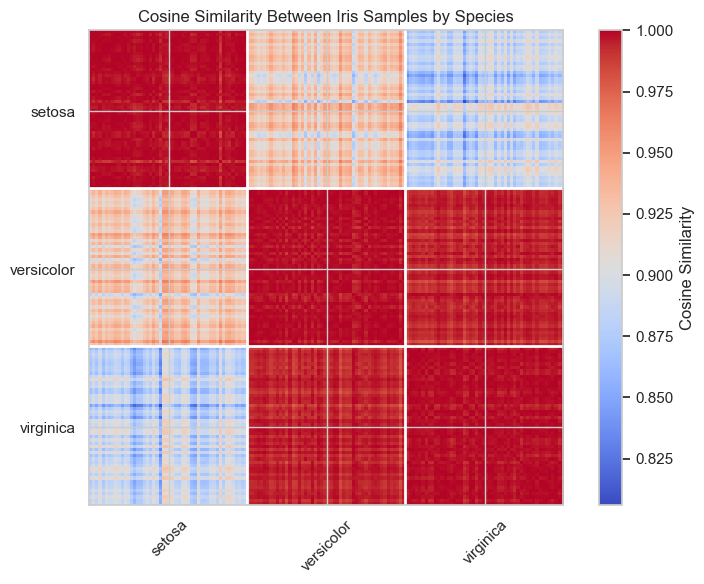

In [23]:
classes = df['species'].unique()
midpoints = [25, 75, 125]  # midpoints for 3 species

plt.figure(figsize=(8,6))
plt.imshow(cos_sim, cmap='coolwarm')

plt.colorbar(label='Cosine Similarity')
plt.xticks(midpoints, classes, rotation=45)
plt.yticks(midpoints, classes)

# Draw lines to separate species blocks
for idx in [50, 100]:
    plt.axhline(idx-0.5, color='white', linewidth=2)
    plt.axvline(idx-0.5, color='white', linewidth=2)

plt.title('Cosine Similarity Between Iris Samples by Species')
plt.tight_layout()

##### Comments:
##### It is verified that similarity reaches its highest values within class samples.
##### 'Setosa' is more distinguishable that both other types.


### Covariance and Correlation Analysis


Covariance measures the joint variability of two variables $X$ and $Y$:

$$
\text{Cov}(X,Y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
$$

Where:  
- $x_i, y_i$ = individual data points  
- $\bar{x}, \bar{y}$ = mean of $X$ and $Y$  
- $n-1$ = Bessel's correction for sample covariance
  
The Pearson correlation coefficient measures the **linear relationship** between two variables $X$ and $Y$:

$$
r = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}
$$

Where:  
- $x_i, y_i$ = individual data points  
- $\bar{x}, \bar{y}$ = mean of $X$ and $Y$  
- $r \in [-1, 1]$:  
  - $r = 1$ → perfect positive correlation  
  - $r = -1$ → perfect negative correlation  
  - $r = 0$ → no linear correlation

**Example calculation steps**:  
1. Compute means: $\bar{x} = \frac{1}{n}\sum x_i$, $\bar{y} = \frac{1}{n}\sum y_i$  
2. Compute deviations: $x_i - \bar{x}, y_i - \bar{y}$  
3. Compute cross-product: $(x_i - \bar{x})(y_i - \bar{y})$  
4. Sum cross-products → numerator  
5. Compute sum of squares of deviations for $X$ and $Y$ → denominator  
6. Divide numerator by denominator → $r$

In [24]:
corr = df.drop('species', axis=1).corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


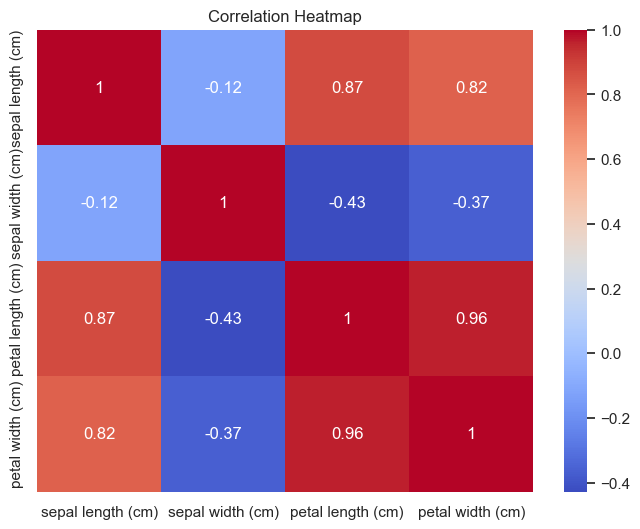

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Cross tabulation (contingency Tabale)

species           setosa  versicolor  virginica
petal_length_cat                               
small                 50           0          0
medium                 0          48          6
large                  0           2         44


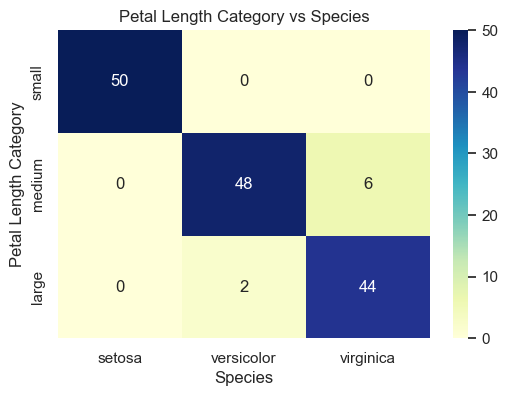

In [26]:
# create categories
df['petal_length_cat'] = pd.cut(  
    df['petal length (cm)'], bins=3,  # 3 equal-width intervals.
    labels=['small','medium','large']) # continuous to discrete # New data from existing one

# contingency table
contingency = pd.crosstab(df['petal_length_cat'], df['species'])

print(contingency)

plt.figure(figsize=(6,4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Petal Length Category vs Species")
plt.ylabel("Petal Length Category")
plt.xlabel("Species")
plt.show()

### Chi-square test " how much the observed counts deviate from what would be expected
Larger value → more deviation → more evidence the variables are related

$$
\chi^2 = \sum_i \sum_j \frac{(O_{i,j} - E_{i,j})^2}{E_{i,j}}
$$

Where:  
- $O_{i,j}$ = observed frequency in row $i$, column $j$  
- $E_{i,j}$ = expected frequency in row $i$, column $j$
$$
p = P(\chi^2_{\text{observed}} \ge \chi^2 \mid H_0)
$$
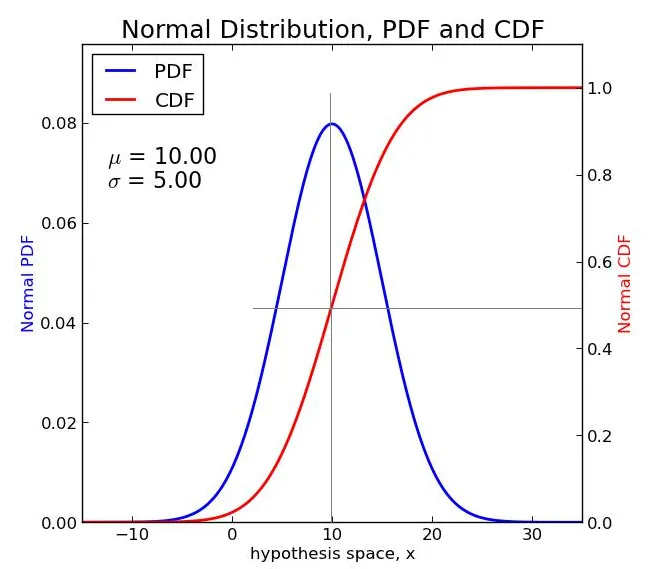
- $H_0$: the null hypothesis that the two categorical variables are independent  
- A small p-value (commonly $< 0.05$) indicates evidence **against $H_0$**, meaning the variables are likely dependent
  
observed >> expected → overrepresented
 
observed << expected → underrepresented

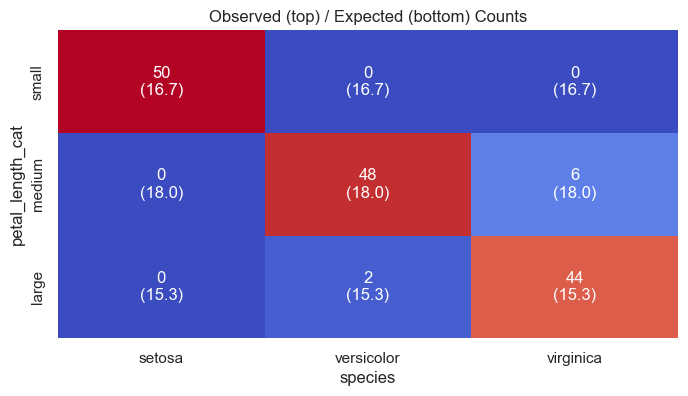

Chi-square: 256.52173913043475
p-value: 2.5614104493043636e-54
Significant relationship


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency

# Contingency table
contingency = pd.crosstab(df['petal_length_cat'], df['species'])

# Chi-square to get expected counts
chi2, p, dof, expected = chi2_contingency(contingency)
expected = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

# Combine observed and expected into annotation strings
annot = contingency.astype(str) + "\n(" + expected.round(1).astype(str) + ")"

# Plot heatmap with both observed and expected
plt.figure(figsize=(8,4))
sns.heatmap(contingency, annot=annot, fmt='', cmap='coolwarm', cbar=False)
plt.title("Observed (top) / Expected (bottom) Counts")
plt.show()

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Significant relationship")
else:
    print("No significant relationship")

### Detecting Outliers Using the IQR Method

In [28]:
# select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# calculate quartiles
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# detect outliers
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))

# count outliers per column
print("Outliers per column:")
print(outliers.sum())

Outliers per column:
sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64


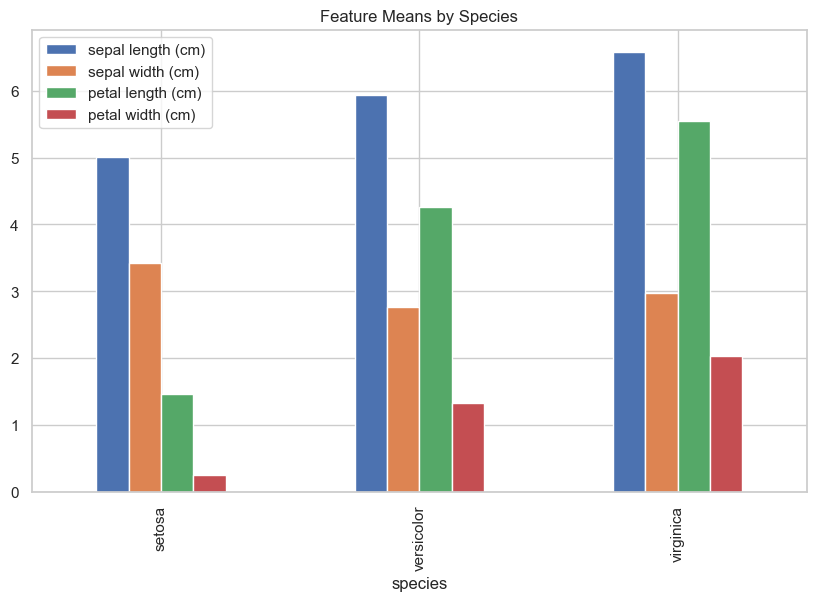

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [29]:
numeric_df = df.select_dtypes(include=[np.number])

means = numeric_df.groupby(df['species']).mean()

means.plot(kind='bar', figsize=(10,6))
plt.title("Feature Means by Species")
plt.show()
means